# Overfitting and Underfitting: Understanding Model Capacity

This notebook explores one of the most fundamental challenges in machine learning: finding the right balance between underfitting and overfitting. We'll use polynomial regression as our playground to build deep intuitions about model capacity and the bias-variance tradeoff.

## The Core Problem

When training machine learning models, we face a delicate balance:

- **Underfitting**: Model is too simple to capture the underlying pattern (high bias)
- **Overfitting**: Model memorizes training data instead of learning generalizable patterns (high variance)
- **Just Right**: Model captures the true pattern and generalizes well to new data

The key is **model capacity** - the model's ability to fit a variety of functions. Too little capacity leads to underfitting, too much leads to overfitting.

## Setup and Imports

We'll use NumPy for data generation, scikit-learn for polynomial regression, and matplotlib for visualization.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Generating Synthetic Data

Let's create a dataset with a known underlying pattern: a cubic function with some noise. This allows us to know the "true" relationship and see how well our models recover it.

In [2]:
def generate_data(n_samples=100, noise=0.1):
    """Generate data from a cubic function with Gaussian noise."""
    X = np.linspace(0, 1, n_samples)
    # True function: cubic with some coefficients
    y_true = 0.5 + 1.5 * X - 3 * X**2 + 2 * X**3
    # Add noise
    y = y_true + np.random.normal(0, noise, n_samples)
    return X.reshape(-1, 1), y, y_true

Create training and test sets. The training set is what our model sees during learning; the test set evaluates generalization.

In [3]:
# Generate training data (smaller, with noise)
X_train, y_train, y_train_true = generate_data(n_samples=30, noise=0.1)

# Generate test data (larger, for smooth visualization)
X_test, y_test, y_test_true = generate_data(n_samples=100, noise=0.1)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 30
Test samples: 100


Let's visualize our data and the true underlying function.

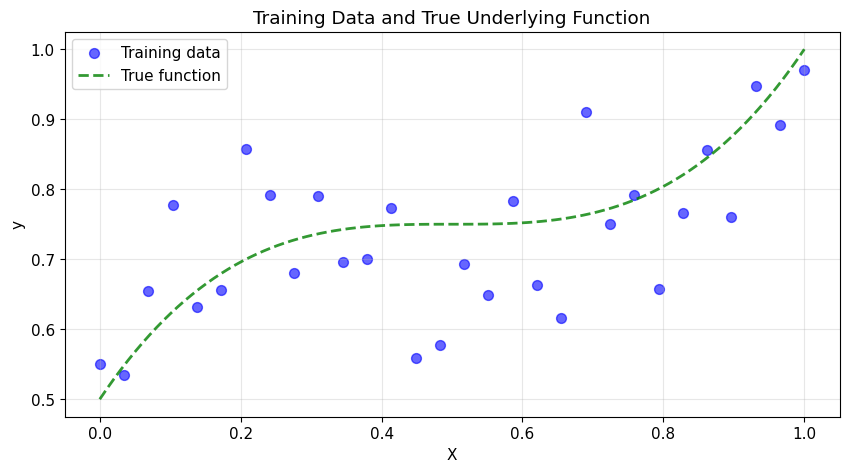

In [4]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, alpha=0.6, s=50, label='Training data', color='blue')
plt.plot(X_test, y_test_true, 'g--', linewidth=2, label='True function', alpha=0.8)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Training Data and True Underlying Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Polynomial Regression: A Model Capacity Playground

Polynomial regression is perfect for understanding model capacity because we can easily control it via the polynomial degree:

- **Degree 1** (Linear): $y = w_0 + w_1x$ → Very limited capacity
- **Degree 3** (Cubic): $y = w_0 + w_1x + w_2x^2 + w_3x^3$ → Moderate capacity
- **Degree 10**: $y = w_0 + w_1x + ... + w_{10}x^{10}$ → Very high capacity

Higher degree = more parameters = higher capacity

Let's create a helper function to fit polynomial models of varying degrees.

In [5]:
def fit_polynomial(X_train, y_train, degree):
    """Fit a polynomial regression model of specified degree."""
    # Transform features to polynomial
    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    X_poly = poly_features.fit_transform(X_train)
    
    # Fit linear regression on polynomial features
    model = LinearRegression()
    model.fit(X_poly, y_train)
    
    return model, poly_features

Helper function to make predictions with our polynomial model.

In [6]:
def predict_polynomial(model, poly_features, X):
    """Make predictions using a fitted polynomial model."""
    X_poly = poly_features.transform(X)
    return model.predict(X_poly)

## Example 1: Underfitting (Degree 1 - Linear)

A linear model has insufficient capacity to capture the cubic relationship in our data. This is **underfitting** - the model is too simple.

In [7]:
# Fit linear model (degree 1)
model_linear, poly_features_linear = fit_polynomial(X_train, y_train, degree=1)

# Make predictions
y_train_pred_linear = predict_polynomial(model_linear, poly_features_linear, X_train)
y_test_pred_linear = predict_polynomial(model_linear, poly_features_linear, X_test)

# Calculate errors
train_mse_linear = mean_squared_error(y_train, y_train_pred_linear)
test_mse_linear = mean_squared_error(y_test, y_test_pred_linear)

print(f"Linear Model (Degree 1):")
print(f"  Training MSE: {train_mse_linear:.4f}")
print(f"  Test MSE: {test_mse_linear:.4f}")

Linear Model (Degree 1):
  Training MSE: 0.0090
  Test MSE: 0.0121


Visualize the linear fit - notice how it cannot capture the curvature.

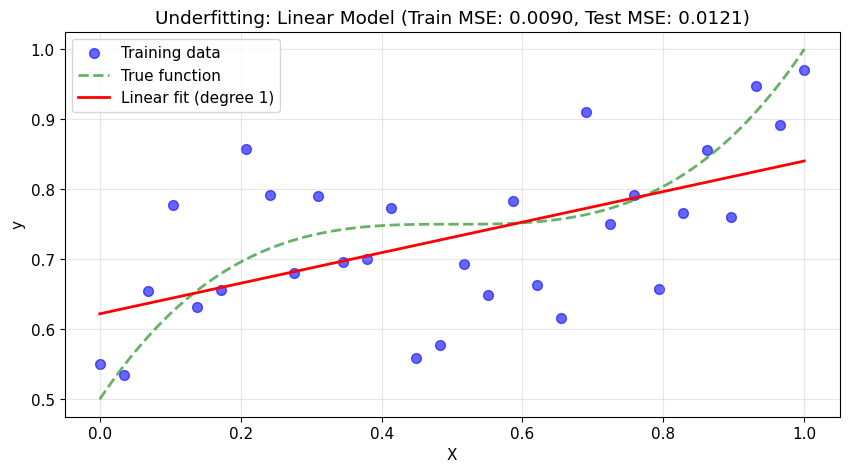

In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, alpha=0.6, s=50, label='Training data', color='blue')
plt.plot(X_test, y_test_true, 'g--', linewidth=2, label='True function', alpha=0.6)
plt.plot(X_test, y_test_pred_linear, 'r-', linewidth=2, label='Linear fit (degree 1)')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Underfitting: Linear Model (Train MSE: {train_mse_linear:.4f}, Test MSE: {test_mse_linear:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key Observation**: Both training and test errors are high. The model is too simple to capture the pattern - this is the hallmark of underfitting.

## Example 2: Good Fit (Degree 3 - Cubic)

Since our true function is cubic, a degree-3 polynomial should fit well. This represents appropriate model capacity.

In [9]:
# Fit cubic model (degree 3)
model_cubic, poly_features_cubic = fit_polynomial(X_train, y_train, degree=3)

# Make predictions
y_train_pred_cubic = predict_polynomial(model_cubic, poly_features_cubic, X_train)
y_test_pred_cubic = predict_polynomial(model_cubic, poly_features_cubic, X_test)

# Calculate errors
train_mse_cubic = mean_squared_error(y_train, y_train_pred_cubic)
test_mse_cubic = mean_squared_error(y_test, y_test_pred_cubic)

print(f"Cubic Model (Degree 3):")
print(f"  Training MSE: {train_mse_cubic:.4f}")
print(f"  Test MSE: {test_mse_cubic:.4f}")

Cubic Model (Degree 3):
  Training MSE: 0.0063
  Test MSE: 0.0113


Visualize the cubic fit - notice how it closely follows the true function.

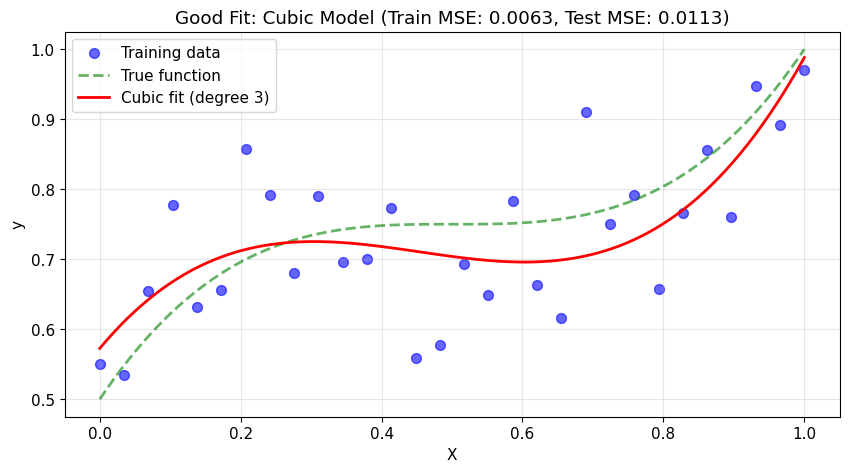

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, alpha=0.6, s=50, label='Training data', color='blue')
plt.plot(X_test, y_test_true, 'g--', linewidth=2, label='True function', alpha=0.6)
plt.plot(X_test, y_test_pred_cubic, 'r-', linewidth=2, label='Cubic fit (degree 3)')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Good Fit: Cubic Model (Train MSE: {train_mse_cubic:.4f}, Test MSE: {test_mse_cubic:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key Observation**: Both training and test errors are low, and they're similar to each other. The model has appropriate capacity.

## Example 3: Overfitting (Degree 15 - Very High Degree)

A degree-15 polynomial has too much capacity. With only 30 training points, it will memorize the noise instead of learning the pattern.

In [11]:
# Fit high-degree model (degree 15)
model_high, poly_features_high = fit_polynomial(X_train, y_train, degree=15)

# Make predictions
y_train_pred_high = predict_polynomial(model_high, poly_features_high, X_train)
y_test_pred_high = predict_polynomial(model_high, poly_features_high, X_test)

# Calculate errors
train_mse_high = mean_squared_error(y_train, y_train_pred_high)
test_mse_high = mean_squared_error(y_test, y_test_pred_high)

print(f"High-Degree Model (Degree 15):")
print(f"  Training MSE: {train_mse_high:.4f}")
print(f"  Test MSE: {test_mse_high:.4f}")

High-Degree Model (Degree 15):
  Training MSE: 0.0045
  Test MSE: 0.0144


Visualize the high-degree fit - notice the wild oscillations between training points.

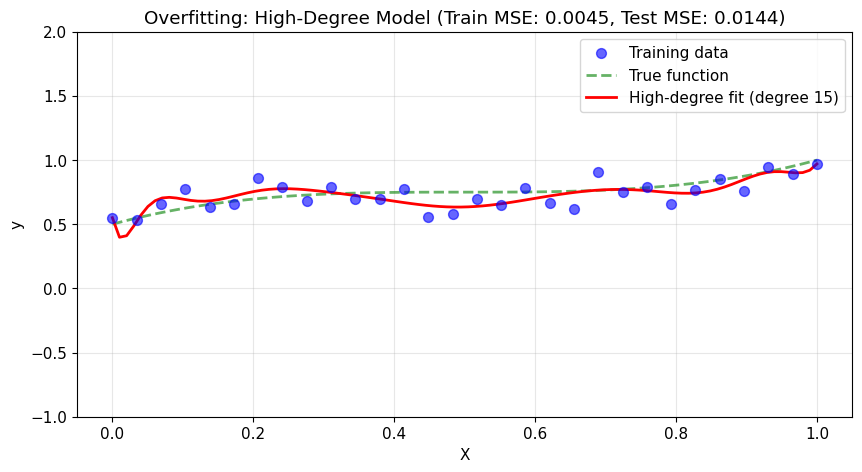

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, alpha=0.6, s=50, label='Training data', color='blue', zorder=3)
plt.plot(X_test, y_test_true, 'g--', linewidth=2, label='True function', alpha=0.6)
plt.plot(X_test, y_test_pred_high, 'r-', linewidth=2, label='High-degree fit (degree 15)')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Overfitting: High-Degree Model (Train MSE: {train_mse_high:.4f}, Test MSE: {test_mse_high:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1, 2)
plt.show()

**Key Observation**: Training error is very low (model fits training data perfectly), but test error is much higher. The large gap indicates overfitting.

## Side-by-Side Comparison

Let's compare all three models together to see the progression from underfitting to good fit to overfitting.

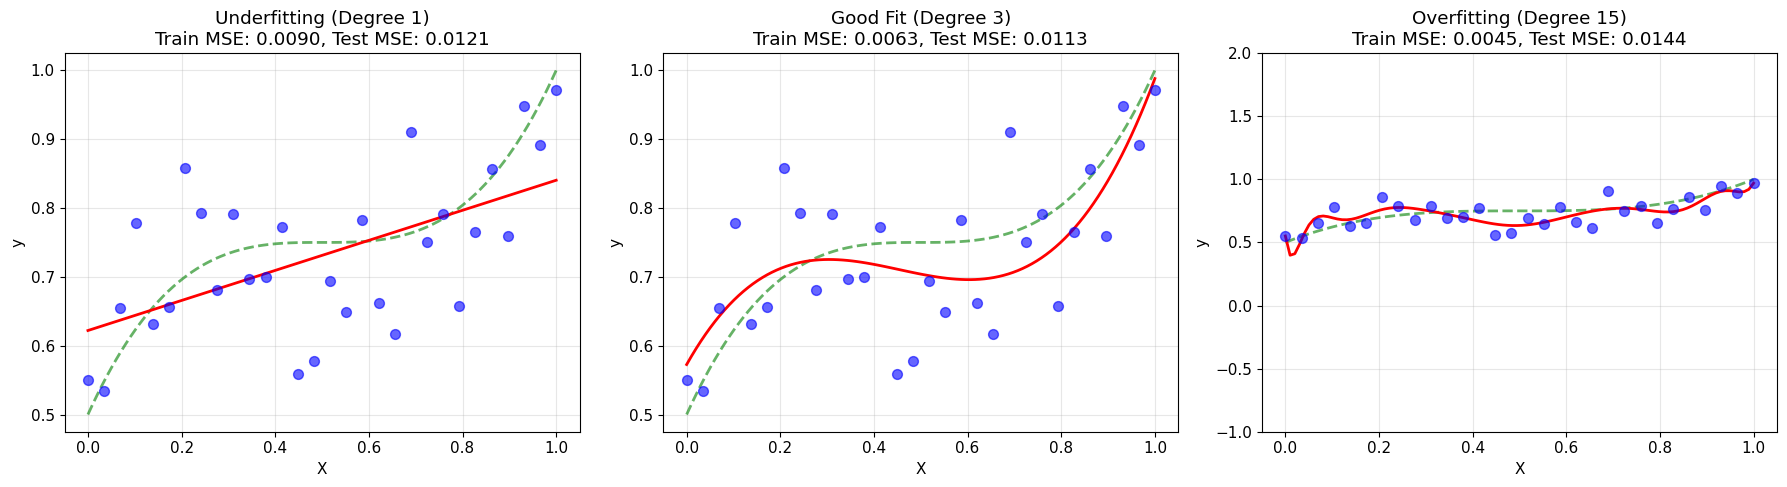

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (model_linear, poly_features_linear, y_test_pred_linear, 1, train_mse_linear, test_mse_linear, 'Underfitting'),
    (model_cubic, poly_features_cubic, y_test_pred_cubic, 3, train_mse_cubic, test_mse_cubic, 'Good Fit'),
    (model_high, poly_features_high, y_test_pred_high, 15, train_mse_high, test_mse_high, 'Overfitting')
]

for ax, (model, poly_feat, y_pred, degree, train_mse, test_mse, label) in zip(axes, models):
    ax.scatter(X_train, y_train, alpha=0.6, s=50, color='blue', zorder=3)
    ax.plot(X_test, y_test_true, 'g--', linewidth=2, alpha=0.6)
    ax.plot(X_test, y_pred, 'r-', linewidth=2)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.set_title(f'{label} (Degree {degree})\nTrain MSE: {train_mse:.4f}, Test MSE: {test_mse:.4f}')
    ax.grid(True, alpha=0.3)
    if degree == 15:
        ax.set_ylim(-1, 2)

plt.tight_layout()
plt.show()

## The Bias-Variance Tradeoff

The relationship between model capacity, underfitting, and overfitting is explained by the **bias-variance tradeoff**:

$$\text{Expected Test Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

- **Bias**: Error from wrong assumptions (e.g., assuming cubic data is linear). High bias → underfitting
- **Variance**: Error from sensitivity to training data noise. High variance → overfitting  
- **Irreducible Error**: Noise in the data that cannot be removed

As model capacity increases:
- Bias ↓ (model can fit more complex patterns)
- Variance ↑ (model becomes more sensitive to noise)

## Model Capacity vs. Error: The Full Spectrum

Let's fit polynomial models of many different degrees (1 through 20) and plot how training and test errors change.

In [14]:
degrees = range(1, 21)
train_errors = []
test_errors = []

for degree in degrees:
    # Fit model
    model, poly_feat = fit_polynomial(X_train, y_train, degree)
    
    # Predictions
    y_train_pred = predict_polynomial(model, poly_feat, X_train)
    y_test_pred = predict_polynomial(model, poly_feat, X_test)
    
    # Errors
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

Plot the training and test errors as a function of polynomial degree (model capacity).

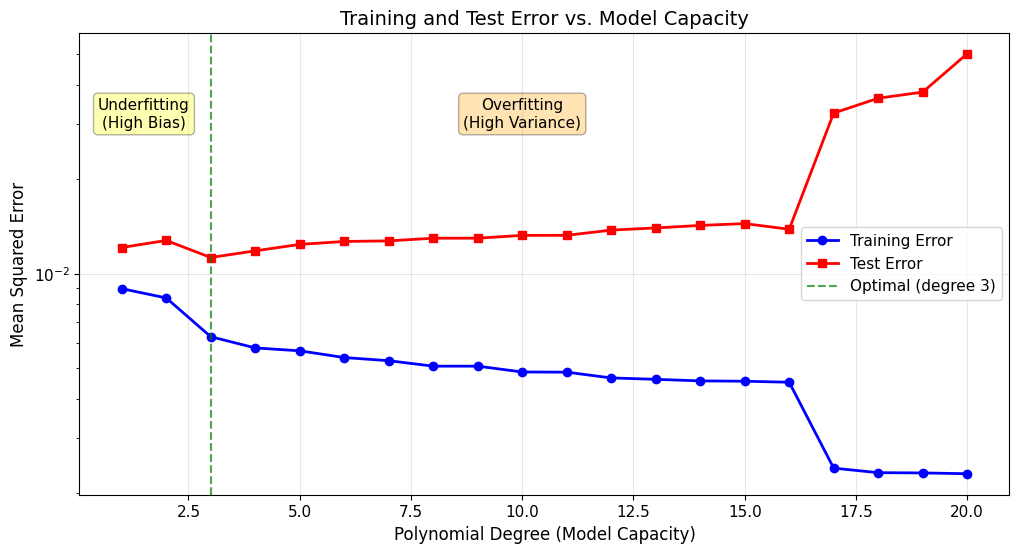

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(degrees, train_errors, 'o-', linewidth=2, markersize=6, label='Training Error', color='blue')
plt.plot(degrees, test_errors, 's-', linewidth=2, markersize=6, label='Test Error', color='red')
plt.axvline(x=3, color='green', linestyle='--', alpha=0.7, label='Optimal (degree 3)')
plt.xlabel('Polynomial Degree (Model Capacity)', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Training and Test Error vs. Model Capacity', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Annotate regions
plt.text(1.5, plt.ylim()[1]*0.5, 'Underfitting\n(High Bias)', fontsize=11, ha='center', 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
plt.text(10, plt.ylim()[1]*0.5, 'Overfitting\n(High Variance)', fontsize=11, ha='center',
         bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))

plt.show()

**Key Observations**:

1. **Training error always decreases** as capacity increases (model can fit training data better)
2. **Test error has a U-shape**: decreases initially, then increases
3. **The gap between curves** indicates overfitting - larger gap means more overfitting
4. **Optimal capacity** is where test error is minimized (around degree 3 for our data)

## Learning Curves: The Effect of Training Data Size

Another way to understand overfitting is through **learning curves** - how model performance changes with the amount of training data.

**Key insight**: More training data helps reduce overfitting!

Let's generate learning curves for our three representative models.

In [16]:
def plot_learning_curve(degree, ax):
    """Generate and plot learning curve for a given polynomial degree."""
    # Generate more data for this analysis
    X_large, y_large, _ = generate_data(n_samples=200, noise=0.1)
    
    train_sizes = np.linspace(10, 150, 15).astype(int)
    train_scores = []
    val_scores = []
    
    for train_size in train_sizes:
        # Use first train_size samples for training
        X_tr = X_large[:train_size]
        y_tr = y_large[:train_size]
        
        # Use remaining for validation
        X_val = X_large[train_size:]
        y_val = y_large[train_size:]
        
        # Fit and evaluate
        model, poly_feat = fit_polynomial(X_tr, y_tr, degree)
        y_tr_pred = predict_polynomial(model, poly_feat, X_tr)
        y_val_pred = predict_polynomial(model, poly_feat, X_val)
        
        train_scores.append(mean_squared_error(y_tr, y_tr_pred))
        val_scores.append(mean_squared_error(y_val, y_val_pred))
    
    ax.plot(train_sizes, train_scores, 'o-', linewidth=2, label='Training Error', color='blue')
    ax.plot(train_sizes, val_scores, 's-', linewidth=2, label='Validation Error', color='red')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Mean Squared Error')
    ax.set_title(f'Learning Curve (Degree {degree})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(max(val_scores), 0.5))

Generate learning curves for linear, cubic, and high-degree models.

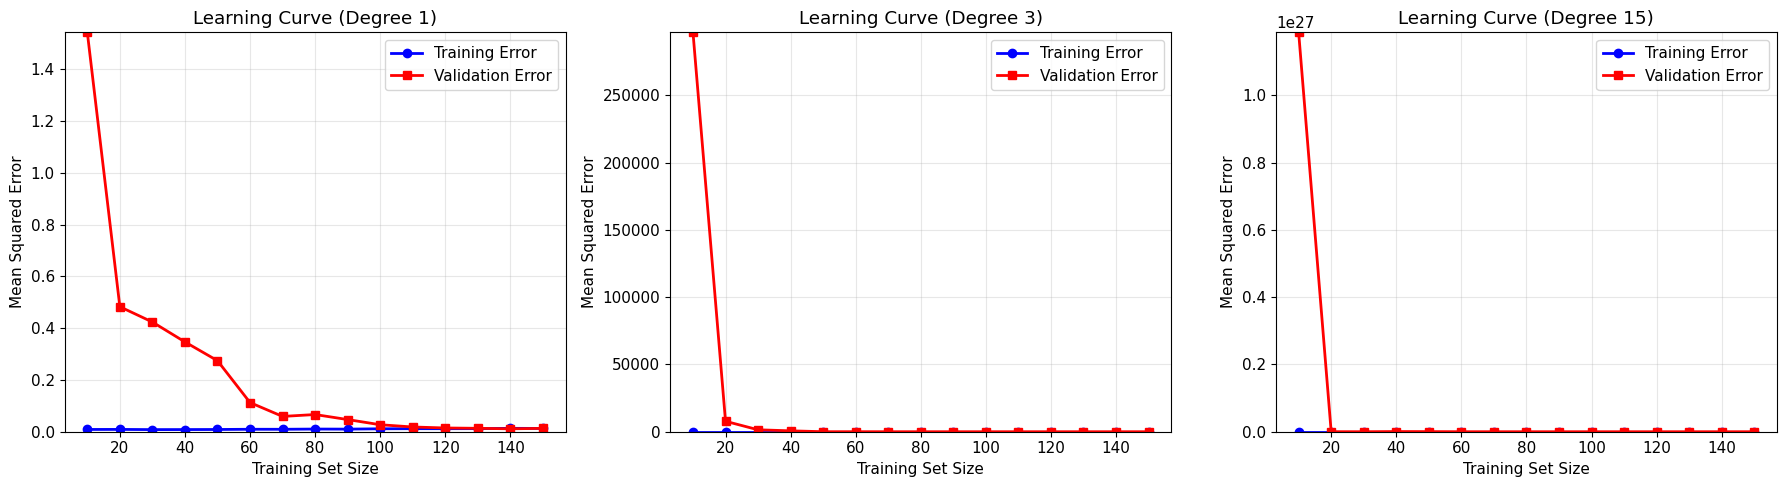

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_learning_curve(1, axes[0])   # Underfitting
plot_learning_curve(3, axes[1])   # Good fit
plot_learning_curve(15, axes[2])  # Overfitting

plt.tight_layout()
plt.show()

## Interpreting Learning Curves

**Underfitting (Degree 1)**:
- Training and validation errors converge to a high value
- Small gap between curves
- More data won't help much - the model is too simple!

**Good Fit (Degree 3)**:
- Both errors converge to a low value
- Small gap between curves
- Model has appropriate capacity for the problem

**Overfitting (Degree 15)**:
- Large gap between training and validation errors
- Training error very low, validation error higher
- Gap shrinks with more data - more data helps reduce overfitting!

## Visualizing Model Predictions Across Degrees

Let's create an animated view of how model predictions change as we increase polynomial degree.

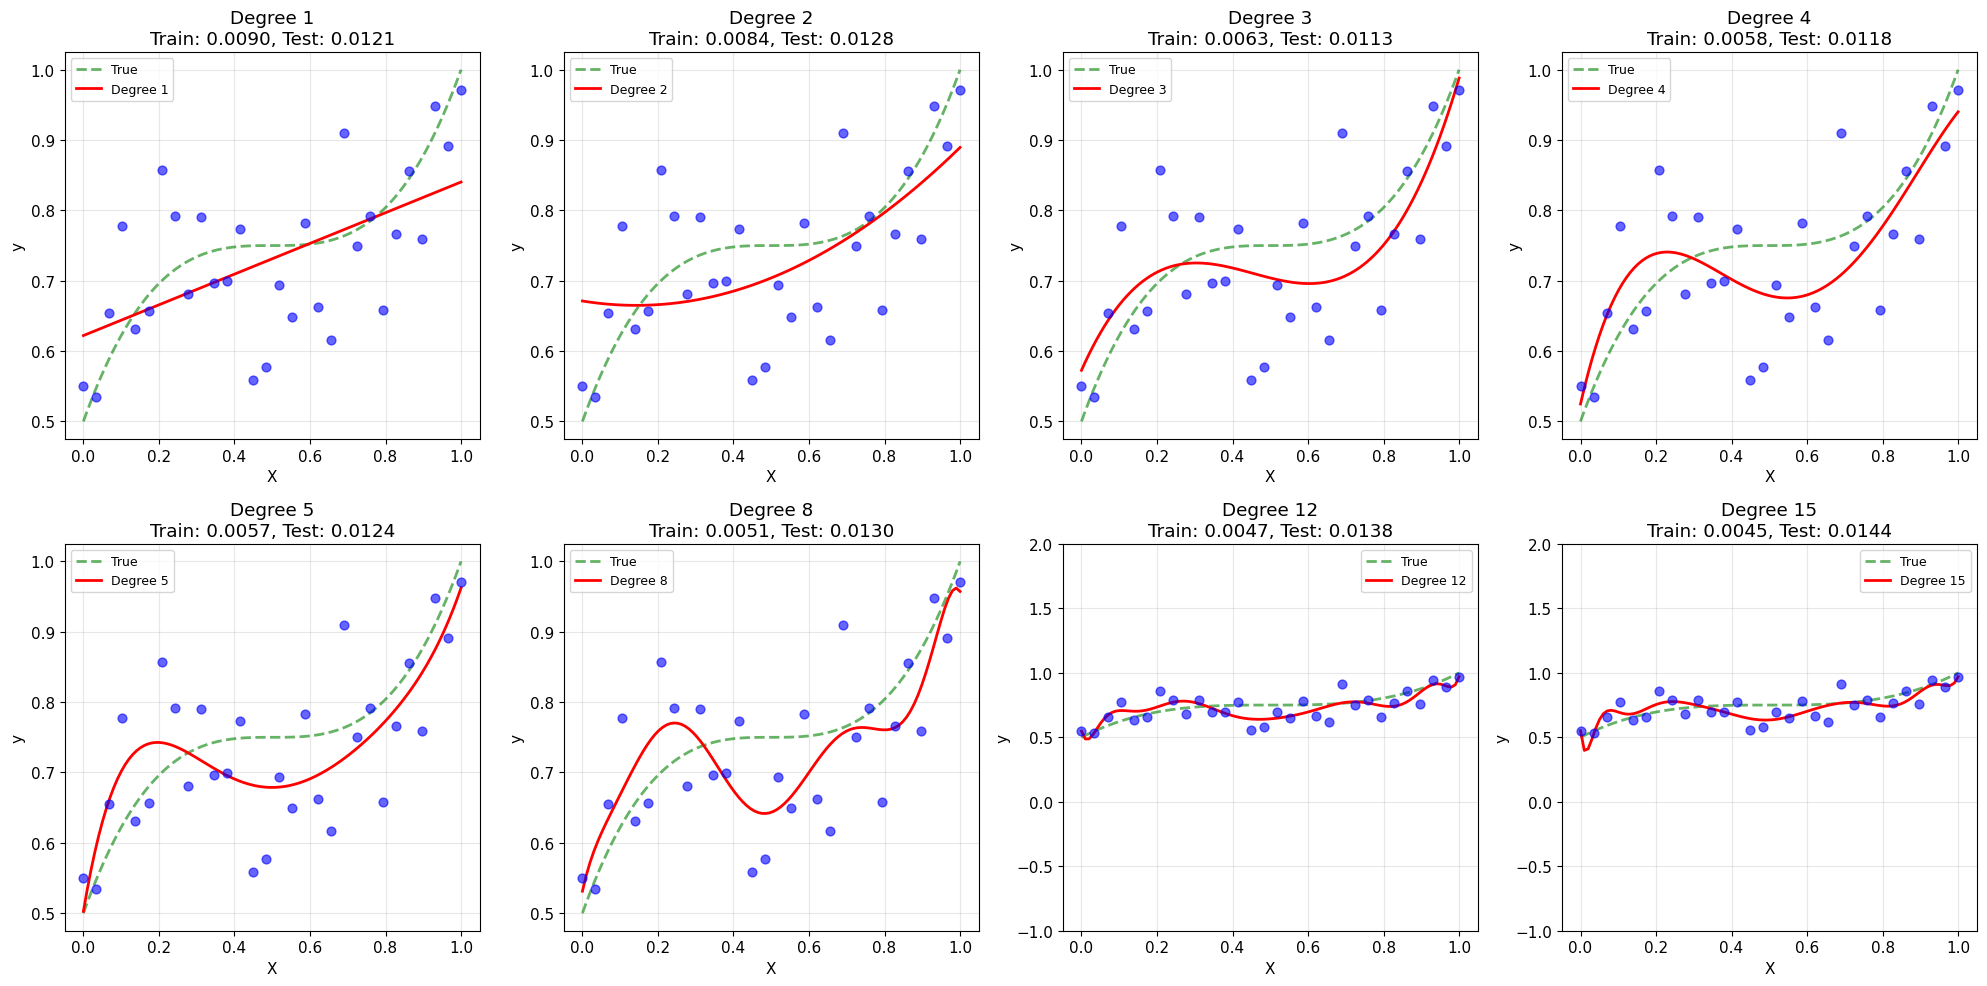

In [18]:
# Select specific degrees to visualize
selected_degrees = [1, 2, 3, 4, 5, 8, 12, 15]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, degree in enumerate(selected_degrees):
    model, poly_feat = fit_polynomial(X_train, y_train, degree)
    y_pred = predict_polynomial(model, poly_feat, X_test)
    
    train_mse = mean_squared_error(y_train, predict_polynomial(model, poly_feat, X_train))
    test_mse = mean_squared_error(y_test, y_pred)
    
    axes[idx].scatter(X_train, y_train, alpha=0.6, s=40, color='blue', zorder=3)
    axes[idx].plot(X_test, y_test_true, 'g--', linewidth=2, alpha=0.6, label='True')
    axes[idx].plot(X_test, y_pred, 'r-', linewidth=2, label=f'Degree {degree}')
    axes[idx].set_title(f'Degree {degree}\nTrain: {train_mse:.4f}, Test: {test_mse:.4f}')
    axes[idx].set_xlabel('X')
    axes[idx].set_ylabel('y')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    
    if degree > 10:
        axes[idx].set_ylim(-1, 2)

plt.tight_layout()
plt.show()

## Practical Implications and Key Takeaways

### How to Detect Overfitting/Underfitting

1. **Underfitting indicators**:
   - High training error
   - High test error
   - Similar training and test errors
   - Model doesn't capture obvious patterns in data

2. **Overfitting indicators**:
   - Low training error
   - High test error (much higher than training)
   - Large gap between training and test performance
   - Model performs well on training data but poorly on new data

### How to Address These Issues

**If underfitting**:
- Increase model capacity (more layers, more units, higher polynomial degree)
- Train longer
- Reduce regularization
- Add more relevant features

**If overfitting**:
- Get more training data (most effective!)
- Reduce model capacity
- Add regularization (L1/L2, dropout)
- Use data augmentation
- Early stopping
- Ensemble methods

### The Golden Rule

**Always use separate training and test sets!** The test set should NEVER be used during training or model selection. This is the only way to get an honest estimate of how your model will perform on new data.

## Summary: The Complete Picture

Let's create one final comprehensive visualization summarizing everything we've learned.

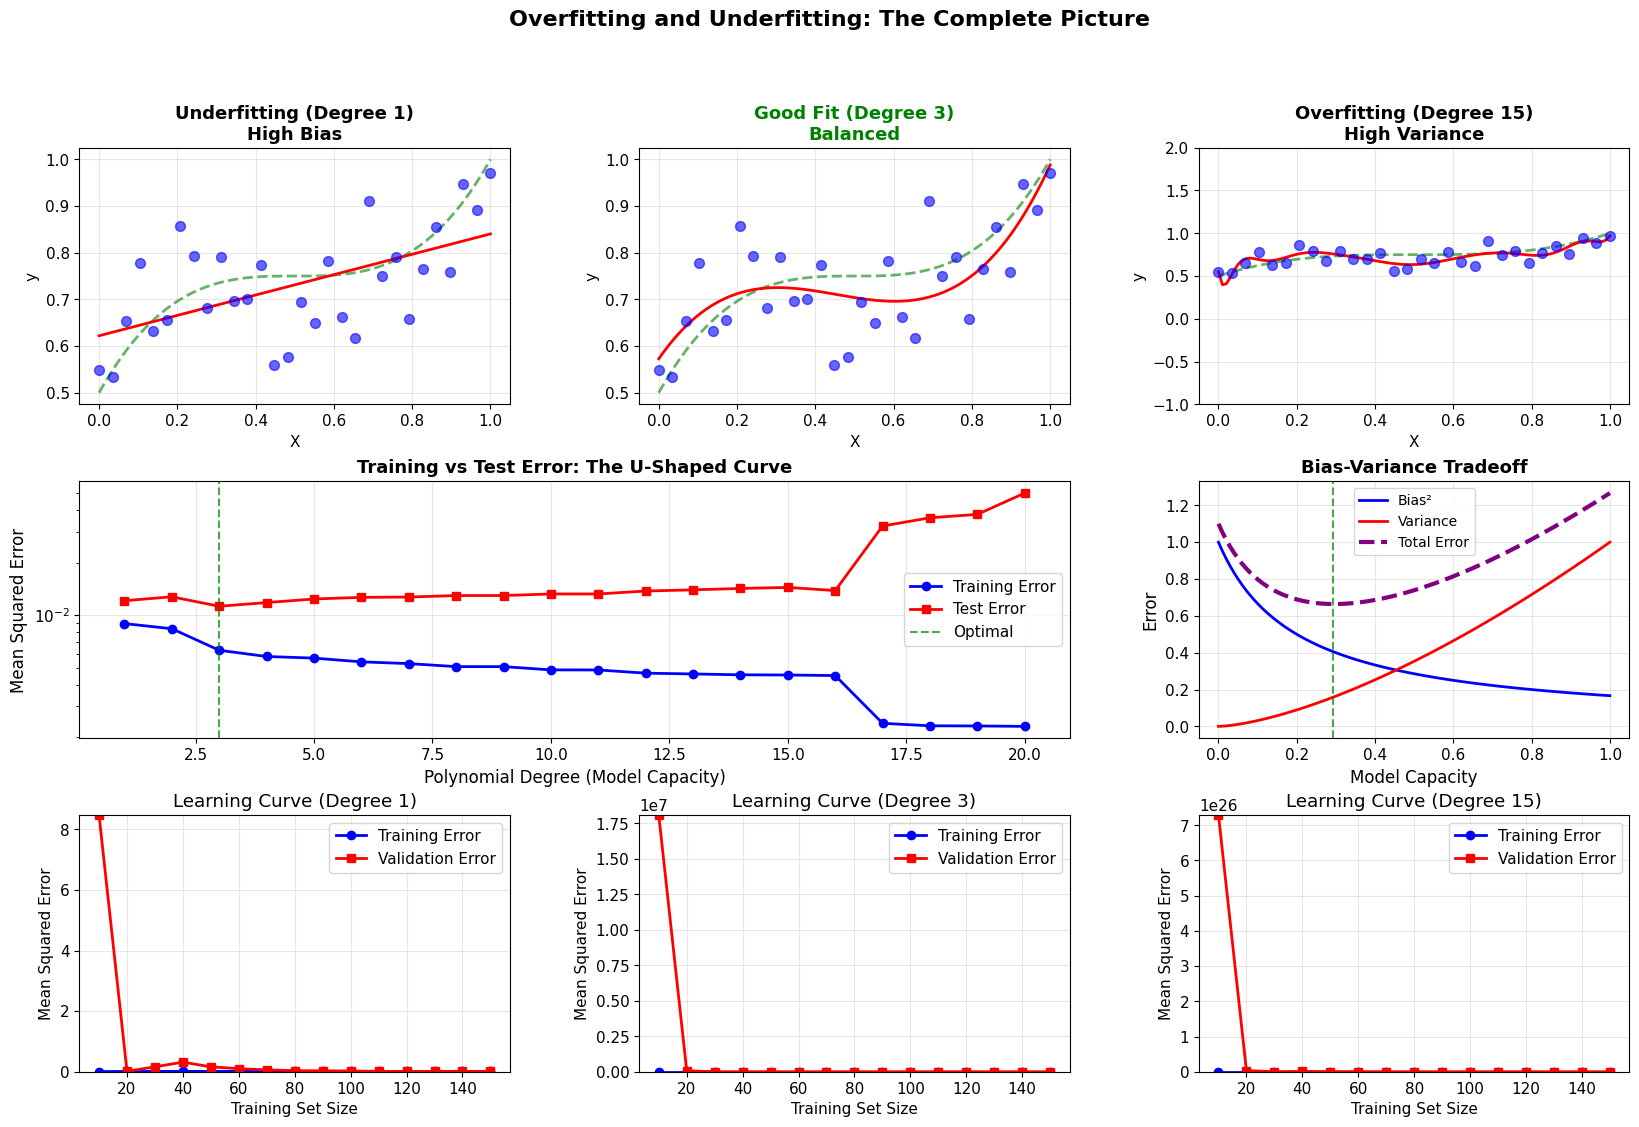

In [19]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Row 1: Three model fits
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(X_train, y_train, alpha=0.6, s=50, color='blue', zorder=3)
ax1.plot(X_test, y_test_true, 'g--', linewidth=2, alpha=0.6)
ax1.plot(X_test, y_test_pred_linear, 'r-', linewidth=2)
ax1.set_title('Underfitting (Degree 1)\nHigh Bias', fontsize=13, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(X_train, y_train, alpha=0.6, s=50, color='blue', zorder=3)
ax2.plot(X_test, y_test_true, 'g--', linewidth=2, alpha=0.6)
ax2.plot(X_test, y_test_pred_cubic, 'r-', linewidth=2)
ax2.set_title('Good Fit (Degree 3)\nBalanced', fontsize=13, fontweight='bold', color='green')
ax2.set_xlabel('X')
ax2.set_ylabel('y')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(X_train, y_train, alpha=0.6, s=50, color='blue', zorder=3)
ax3.plot(X_test, y_test_true, 'g--', linewidth=2, alpha=0.6)
ax3.plot(X_test, y_test_pred_high, 'r-', linewidth=2)
ax3.set_title('Overfitting (Degree 15)\nHigh Variance', fontsize=13, fontweight='bold')
ax3.set_xlabel('X')
ax3.set_ylabel('y')
ax3.set_ylim(-1, 2)
ax3.grid(True, alpha=0.3)

# Row 2: Model capacity vs error curve (spanning 2 columns)
ax4 = fig.add_subplot(gs[1, :2])
ax4.plot(degrees, train_errors, 'o-', linewidth=2, markersize=6, label='Training Error', color='blue')
ax4.plot(degrees, test_errors, 's-', linewidth=2, markersize=6, label='Test Error', color='red')
ax4.axvline(x=3, color='green', linestyle='--', alpha=0.7, label='Optimal')
ax4.set_xlabel('Polynomial Degree (Model Capacity)', fontsize=12)
ax4.set_ylabel('Mean Squared Error', fontsize=12)
ax4.set_title('Training vs Test Error: The U-Shaped Curve', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.set_yscale('log')

# Row 2, Column 3: Bias-Variance tradeoff diagram
ax5 = fig.add_subplot(gs[1, 2])
capacity = np.linspace(0, 1, 100)
bias = 1 / (1 + 5*capacity)  # Decreases with capacity
variance = capacity ** 1.5  # Increases with capacity
total_error = bias + variance + 0.1

ax5.plot(capacity, bias, linewidth=2, label='Bias²', color='blue')
ax5.plot(capacity, variance, linewidth=2, label='Variance', color='red')
ax5.plot(capacity, total_error, linewidth=3, label='Total Error', color='purple', linestyle='--')
optimal_idx = np.argmin(total_error)
ax5.axvline(x=capacity[optimal_idx], color='green', linestyle='--', alpha=0.7)
ax5.set_xlabel('Model Capacity', fontsize=12)
ax5.set_ylabel('Error', fontsize=12)
ax5.set_title('Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# Row 3: Learning curves
ax6 = fig.add_subplot(gs[2, 0])
plot_learning_curve(1, ax6)

ax7 = fig.add_subplot(gs[2, 1])
plot_learning_curve(3, ax7)

ax8 = fig.add_subplot(gs[2, 2])
plot_learning_curve(15, ax8)

plt.suptitle('Overfitting and Underfitting: The Complete Picture', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## Conclusion

We've explored the fundamental machine learning challenge of balancing model capacity:

1. **Underfitting** occurs when models are too simple (high bias)
2. **Overfitting** occurs when models are too complex (high variance)
3. **The sweet spot** balances bias and variance for optimal generalization
4. **Training vs test error gap** is the key indicator of overfitting
5. **More data helps** reduce overfitting by constraining the model

These concepts apply to all machine learning models, not just polynomial regression. Whether you're training deep neural networks, decision trees, or any other model, you'll always need to navigate the bias-variance tradeoff.

**Remember**: The goal isn't to minimize training error - it's to build models that generalize well to unseen data!